In [2]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from Exp1.Exp1 import perform_eda

Dataset: Loan Amount Prediction
Shape: (30000, 24)
------------------------------------------------------------
Column Types:
Customer ID                        str
Name                               str
Gender                             str
Age                              int64
Income (USD)                   float64
Income Stability                   str
Profession                         str
Type of Employment                 str
Location                           str
Loan Amount Request (USD)      float64
Current Loan Expenses (USD)    float64
Expense Type 1                     str
Expense Type 2                     str
Dependents                     float64
Credit Score                   float64
No. of Defaults                  int64
Has Active Credit Card             str
Property ID                      int64
Property Age                   float64
Property Type                    int64
Property Location                  str
Co-Applicant                     int64
Property Price  

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


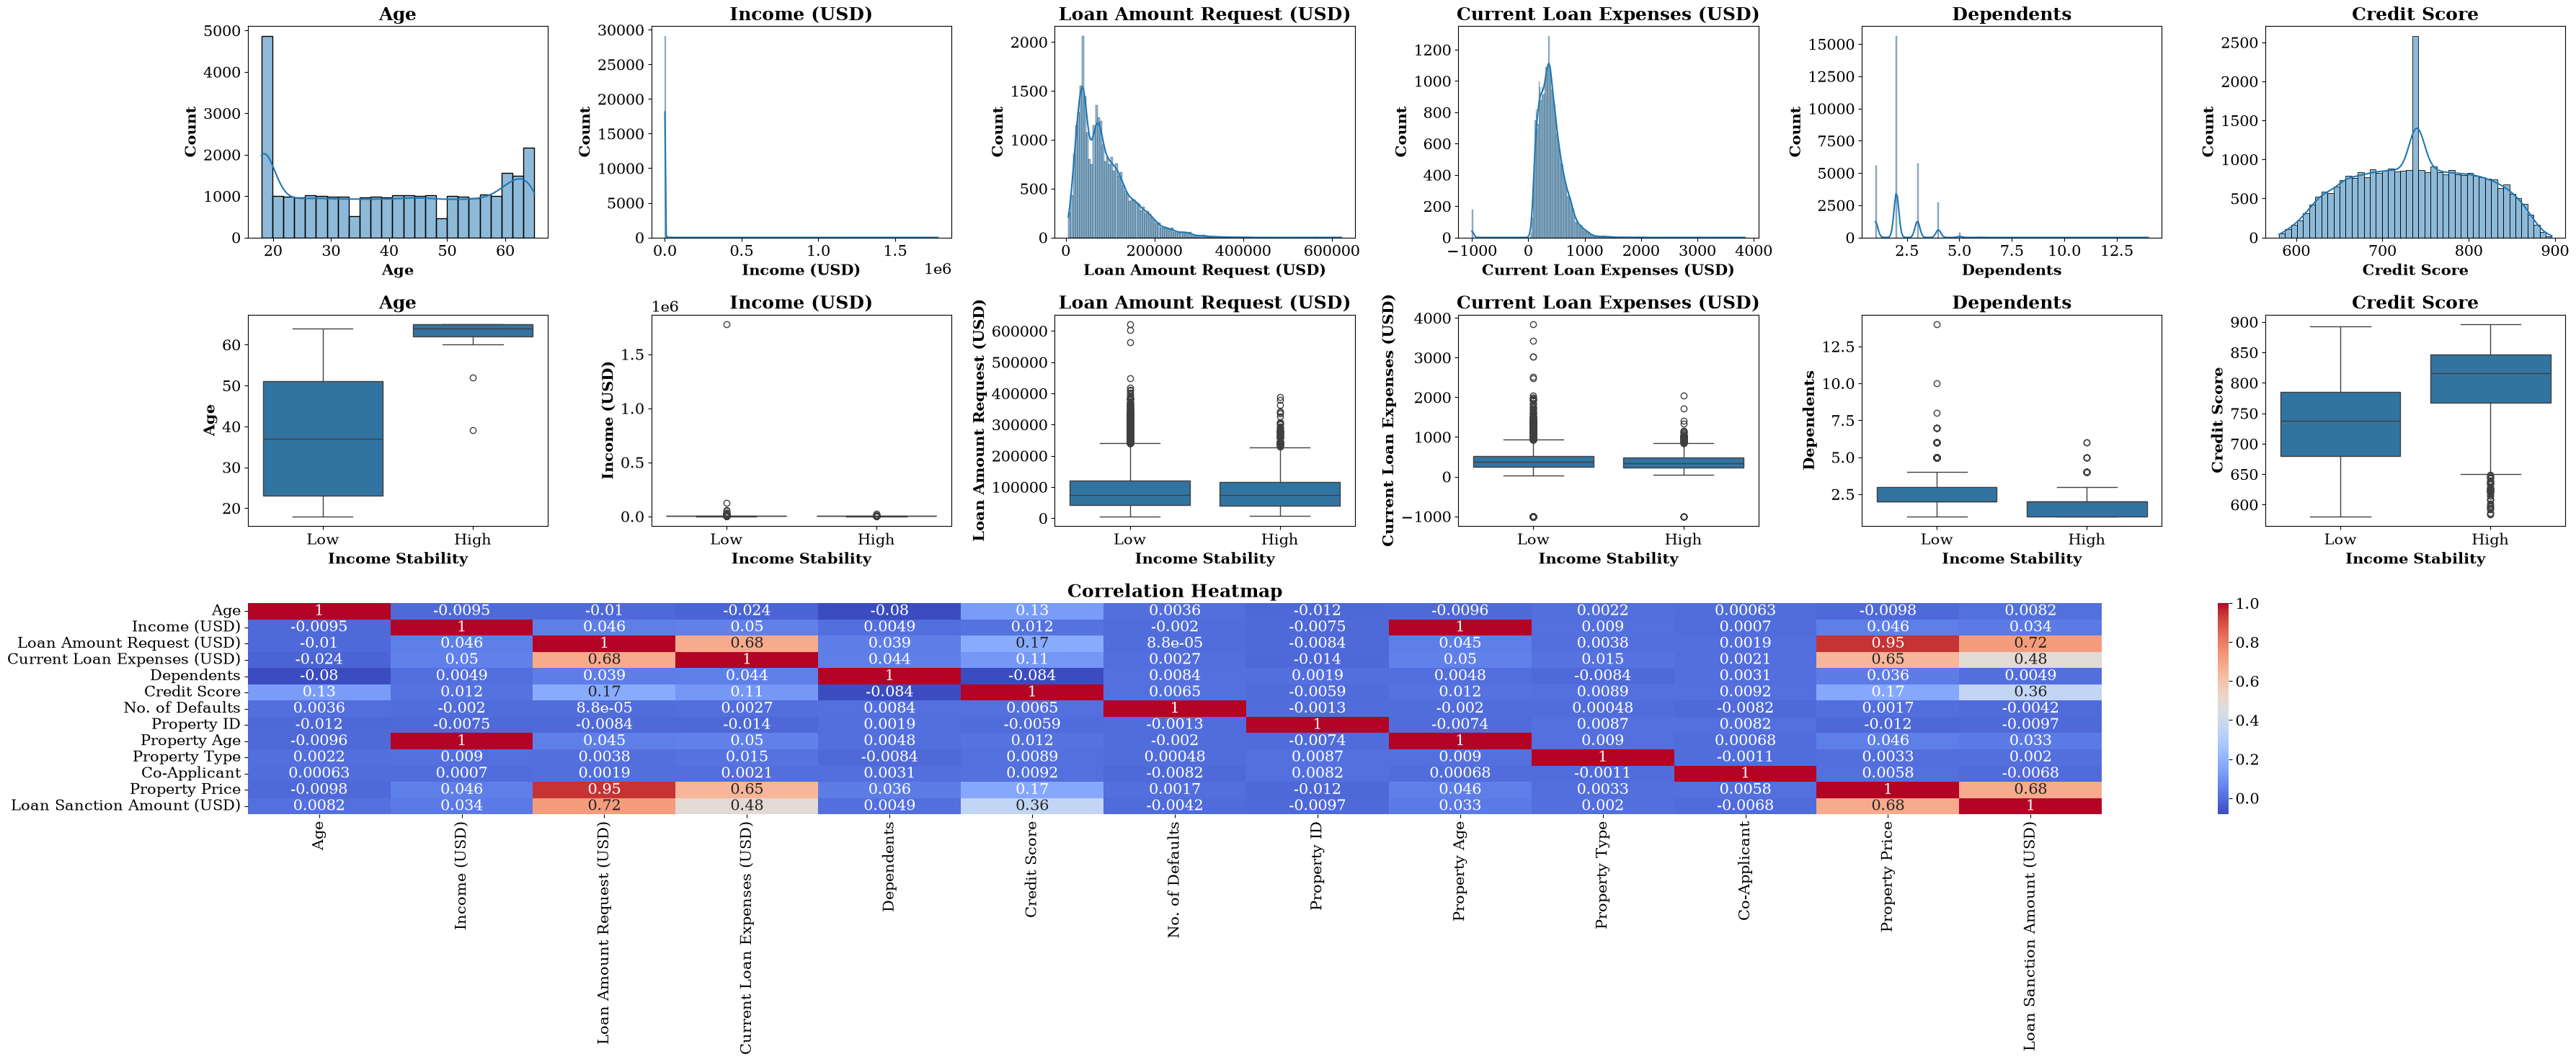

Age
Mean: 40.0923
Median: 40.0
Std Dev: 16.04512892589965
Min: 18
Max: 65
Q1: 25.0
Q3: 55.0
Skewness: 0.046093801598670575
Kurtosis: -1.3820829377043198

Income (USD)
Mean: 2568.319551666667
Median: 2222.435
Std Dev: 10369.240277221474
Min: 377.7
Max: 1777460.21
Q1: 1743.3049999999998
Q3: 2869.1425
Skewness: 167.25404149415033
Kurtosis: 28618.336110342498

Loan Amount Request (USD)
Mean: 88826.33385533333
Median: 75128.075
Std Dev: 59536.9496048716
Min: 6048.24
Max: 621497.82
Q1: 41177.755000000005
Q3: 119964.605
Skewness: 1.2603921833589768
Kurtosis: 2.1033795372721813

Current Loan Expenses (USD)
Mean: 400.789347
Median: 375.205
Std Dev: 241.85685890081106
Min: -999.0
Max: 3840.88
Q1: 248.655
Q3: 520.1025
Skewness: 0.04627463900449087
Kurtosis: 10.828683468529654

Dependents
Mean: 2.232
Median: 2.0
Std Dev: 0.9134570671139661
Min: 1.0
Max: 14.0
Q1: 2.0
Q3: 3.0
Skewness: 0.9003711739556094
Kurtosis: 1.8214530756905343

Credit Score
Mean: 739.8816696666667
Median: 739.82
Std Dev: 70.08

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.050,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.910,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.190,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,2222.435,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,2223.25,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.770,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,C-43723,Angelyn Clevenger,M,38,4969.410,Low,Commercial associate,Managers,Urban,76657.90,...,869.61,0,Unpossessed,566,4969.41,4,Urban,1,111096.56,68992.11
29996,C-32511,Silas Slaugh,M,20,1606.880,Low,Working,Laborers,Semi-Urban,66595.14,...,729.41,0,Inactive,175,1606.88,3,Urban,1,73453.94,46616.60
29997,C-5192,Carmelo Lone,F,49,2222.435,Low,Working,Sales staff,Urban,81410.08,...,739.82,0,Active,959,2223.25,1,Rural,1,102108.02,61057.56
29998,C-12172,Carolann Osby,M,38,2417.710,Low,Working,Security staff,Semi-Urban,142524.10,...,677.27,1,Unpossessed,375,2417.71,4,Urban,1,168194.47,99766.87


In [3]:
# Perform EDA

df = pd.read_csv('train.csv')
perform_eda(df, dataset_name='Loan Amount Prediction')

In [4]:
# Split the dataset into training and testing sets

# ALREADY DONE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')  # no target column — for final predictions only

target = 'Loan Sanction Amount (USD)'
drop_cols = ['Customer ID', 'Name', target]


X = train.drop(columns=drop_cols)
y = train[target]

# Drop rows where target itself is missing
mask = y.notna()
X, y = X[mask], y[mask]

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# Simple imputation for numeric NaNs
X = X.fillna(X.median(numeric_only=True))

# Split off a validation set from train (since test.csv has no labels)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

In [5]:
# Baseline Linear Regression

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score


model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_val)
print("RMSE:", root_mean_squared_error(y_val, preds))
print("R²:", r2_score(y_val, preds))



RMSE: 31846.384541452357
R²: 0.5531749151147344


In [6]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge = Ridge()
lasso = Lasso()
enet = ElasticNet()

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
enet.fit(X_train, y_train)

/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.907089e+12, tolerance: 5.550e+09
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [7]:
from sklearn.model_selection import GridSearchCV

ridge_grid = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='neg_root_mean_squared_error')
lasso_grid = GridSearchCV(Lasso(), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='neg_root_mean_squared_error')
enet_grid = GridSearchCV(ElasticNet(), {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]}, cv=5, scoring='neg_root_mean_squared_error')

ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)
enet_grid.fit(X_train, y_train)

ridge_best = ridge_grid.best_estimator_
lasso_best = lasso_grid.best_estimator_
enet_best = enet_grid.best_estimator_

print("Ridge best alpha:", ridge_grid.best_params_)
print("Lasso best alpha:", lasso_grid.best_params_)
print("ElasticNet best params:", enet_grid.best_params_)

/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.982763e+12, tolerance: 4.482e+09
  model = cd_fast.enet_coordinate_descent(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.872917e+12, tolerance: 4.471e+09
  model = cd_fast.enet_coordinate_descent(
/home/sarav/Projects/ML-Lab/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

Ridge best alpha: {'alpha': 100}
Lasso best alpha: {'alpha': 100}
ElasticNet best params: {'alpha': 0.1, 'l1_ratio': 0.5}


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': model,
    'Ridge': ridge_best,
    'Lasso': lasso_best,
    'Elastic Net': enet_best
}

results = []
train_errors = []
val_errors = []

for name, model in models.items():
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    r2 = r2_score(y_val, val_preds)

    results.append({'Model': name, 'RMSE': val_rmse, 'R2': r2})
    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

results_df = pd.DataFrame(results)
print(results_df)

               Model          RMSE        R2
0  Linear Regression  31846.384541  0.553175
1              Ridge  31829.159555  0.553658
2              Lasso  31813.396490  0.554100
3        Elastic Net  31861.269357  0.552757


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


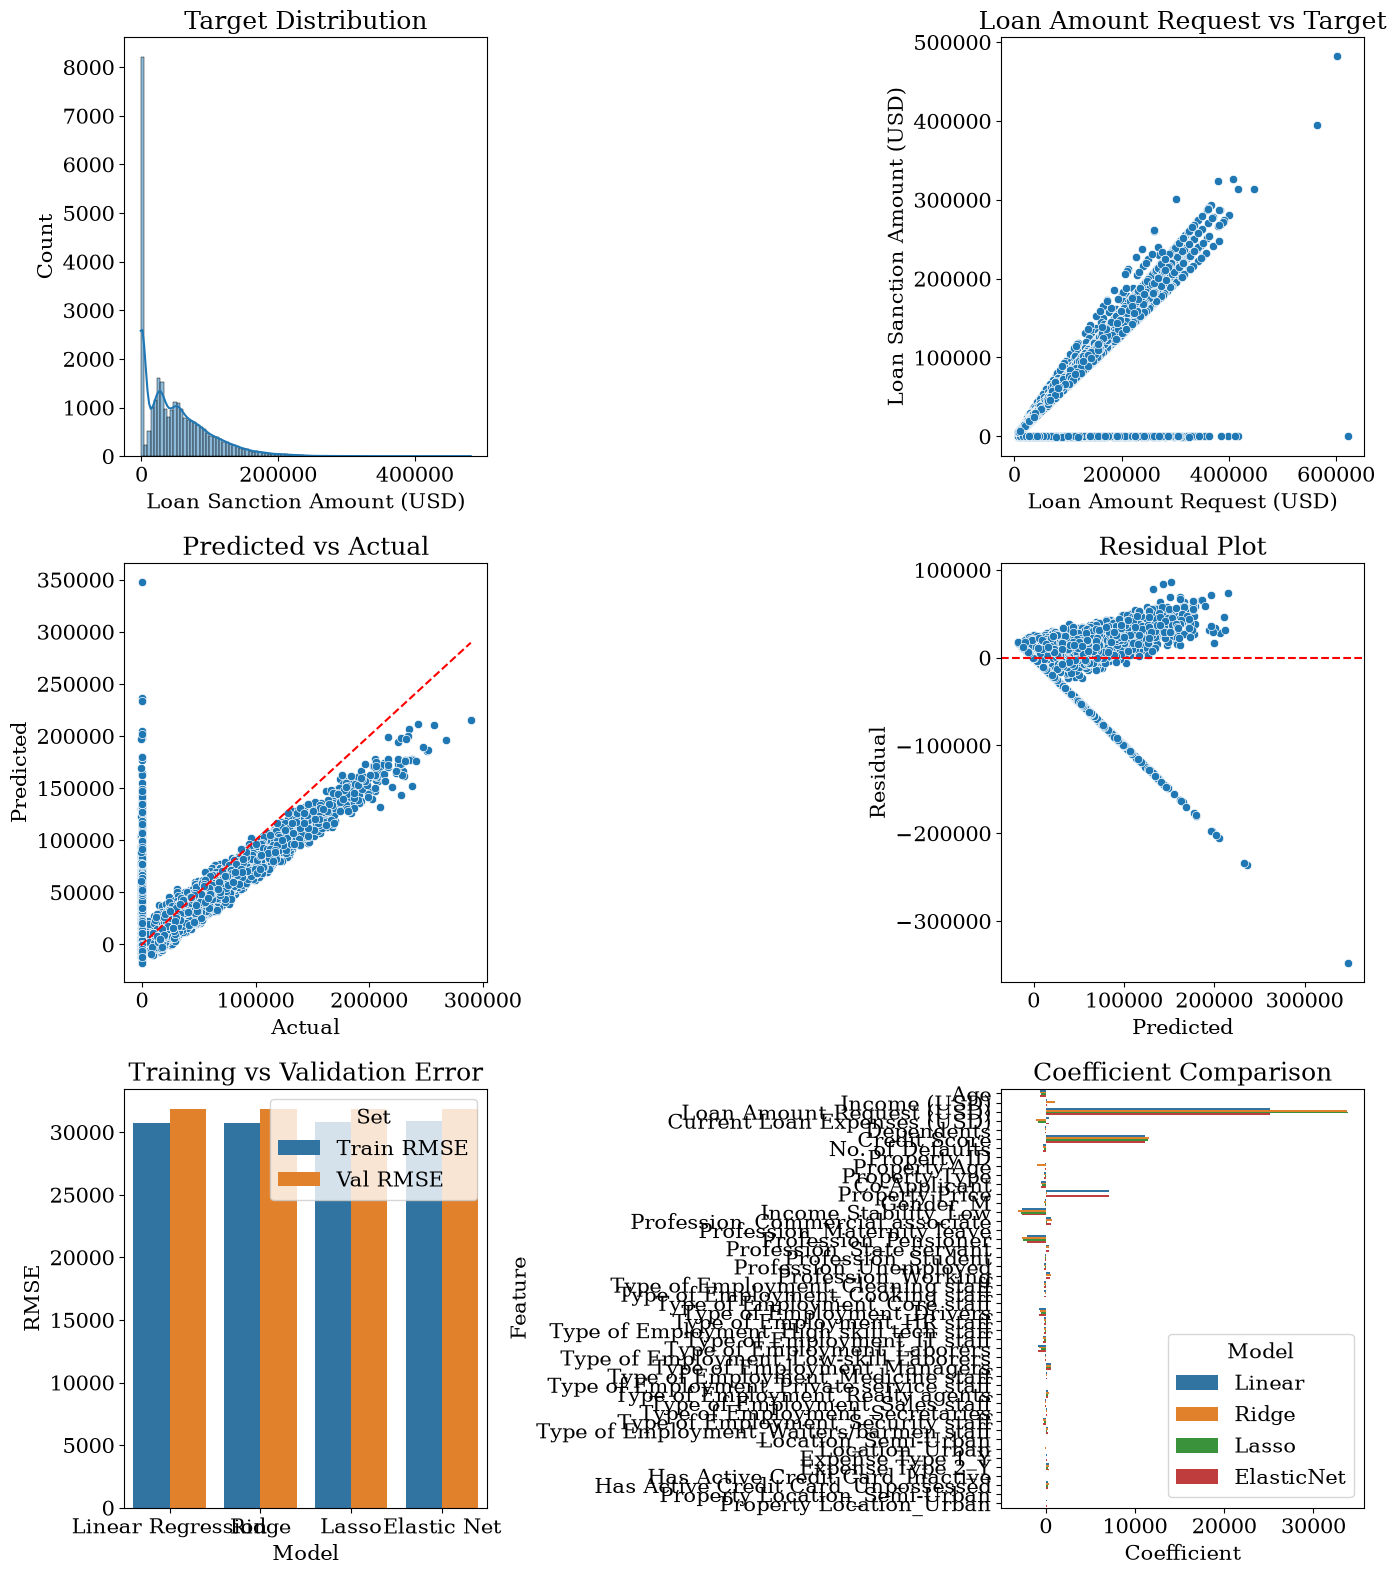

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

sns.histplot(y, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Target Distribution')

sns.scatterplot(x=train['Loan Amount Request (USD)'], y=train[target], ax=axes[0, 1])
axes[0, 1].set_title('Loan Amount Request vs Target')

best_model = ridge_best
preds = best_model.predict(X_val)
sns.scatterplot(x=y_val, y=preds, ax=axes[1, 0])
axes[1, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')
axes[1, 0].set_title('Predicted vs Actual')

residuals = y_val - preds
sns.scatterplot(x=preds, y=residuals, ax=axes[1, 1])
axes[1, 1].axhline(0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Residual Plot')

error_df = pd.DataFrame({'Model': list(models.keys()), 'Train RMSE': train_errors, 'Val RMSE': val_errors})
error_df_melted = error_df.melt(id_vars='Model', var_name='Set', value_name='RMSE')
sns.barplot(data=error_df_melted, x='Model', y='RMSE', hue='Set', ax=axes[2, 0])
axes[2, 0].set_title('Training vs Validation Error')

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear': model.coef_,
    'Ridge': ridge_best.coef_,
    'Lasso': lasso_best.coef_,
    'ElasticNet': enet_best.coef_
})
coef_df_melted = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
sns.barplot(data=coef_df_melted, y='Feature', x='Coefficient', hue='Model', ax=axes[2, 1])
axes[2, 1].set_title('Coefficient Comparison')

os.makedirs('./images', exist_ok=True)

plt.tight_layout()
plt.savefig('./images/combined_plots.eps', format='eps', dpi=600)
plt.show()



In [11]:
print(coef_df.to_string(index=False))

                                 Feature       Linear        Ridge        Lasso   ElasticNet
                                     Age  -637.481139  -610.626981  -541.417786  -637.481139
                            Income (USD)    98.713615  1010.253395     0.000000    98.713615
               Loan Amount Request (USD) 25097.326091 33733.801273 33819.379004 25097.326091
             Current Loan Expenses (USD)   314.361667 -1043.418606  -893.924162   314.361667
                              Dependents   -46.281314   -79.876977    -0.000000   -46.281314
                            Credit Score 11107.977887 11528.028578 11490.804998 11107.977887
                         No. of Defaults  -275.581014  -270.105076  -178.008446  -275.581014
                             Property ID    42.844310     0.229220    -0.000000    42.844310
                            Property Age   -76.010224  -986.137046     0.000000   -76.010224
                           Property Type  -200.015820  -197.412442  -1

In [12]:
import numpy as np
import time
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'MSE': make_scorer(mean_squared_error),
    'RMSE': make_scorer(rmse_scorer),
    'R2': make_scorer(r2_score),
}

# Re-init models with best params (already fitted, but cross_validate re-fits internally)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

cv_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=100),
    'Lasso Regression':  Lasso(alpha=100),
    'Elastic Net':       ElasticNet(alpha=0.1, l1_ratio=0.5),
}

print("=== Table 2: Cross-Validation Performance (K=5) ===")
for name, m in cv_models.items():
    cv = cross_validate(m, X_train, y_train, cv=5, scoring=scoring)
    print(f"{name}: MAE={-cv['test_MAE'].mean():.2f}, MSE={-cv['test_MSE'].mean():.2f}, "
          f"RMSE={-cv['test_RMSE'].mean():.2f}, R2={cv['test_R2'].mean():.4f}")

print()
print("=== Table 3: Test Set Performance ===")
for name, m in cv_models.items():
    t0 = time.time()
    m.fit(X_train, y_train)
    elapsed = time.time() - t0
    preds = m.predict(X_val)
    mae  = mean_absolute_error(y_val, preds)
    mse  = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_val, preds)
    print(f"{name}: MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}, Time={elapsed:.4f}s")

=== Table 2: Cross-Validation Performance (K=5) ===
Linear Regression: MAE=-21496.61, MSE=-1004166156.30, RMSE=-31661.09, R2=0.5707
Ridge Regression: MAE=-21515.63, MSE=-990045314.89, RMSE=-31450.50, R2=0.5766
Lasso Regression: MAE=-21451.47, MSE=-952919587.15, RMSE=-30860.63, R2=0.5920
Elastic Net: MAE=-21696.42, MSE=-968671506.34, RMSE=-31117.83, R2=0.5853

=== Table 3: Test Set Performance ===
Linear Regression: MAE=21541.82, MSE=1014192208.36, RMSE=31846.38, R2=0.5532, Time=0.0200s
Ridge Regression: MAE=21546.50, MSE=1013095397.97, RMSE=31829.16, R2=0.5537, Time=0.0116s
Lasso Regression: MAE=21527.71, MSE=1012092196.21, RMSE=31813.40, R2=0.5541, Time=0.1314s
Elastic Net: MAE=21727.61, MSE=1015140485.01, RMSE=31861.27, R2=0.5528, Time=0.0787s
